In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
train_df = pd.read_csv('../results/outputs/Splits Stress_level_dataset/stress_level_train_scaled.csv')
test_df = pd.read_csv('../results/outputs/Splits Stress_level_dataset/stress_level_test_scaled.csv')

In [19]:
train_df.shape

(897, 21)

In [20]:
test_df.shape

(220, 21)

In [21]:
train_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,target
0,13,25,1,10,2,1,2,2,2,2,...,3,3,2,3,2,2,3,3,2,1
1,19,11,1,25,4,3,1,5,5,1,...,2,1,4,2,4,1,5,5,5,2
2,1,25,0,3,1,2,5,1,1,4,...,4,4,1,4,1,3,1,2,1,0
3,15,10,1,17,4,3,1,5,5,1,...,2,1,5,1,4,1,5,4,5,2
4,7,27,0,0,1,2,4,2,2,3,...,4,4,1,4,1,3,2,1,1,0


In [22]:
test_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,target
0,-0.492268,1.243686,0,-1.500495,-1.064830,-0.225935,1.516182,-0.521307,-1.240155,0.427672,...,0.835473,1.569470,-0.453969,1.676809,-1.068132,1.074062,-0.516479,-0.535859,-1.067918,0
1,-0.653607,0.795832,0,-1.111445,-1.064830,-0.225935,1.516182,-1.236986,-0.489063,0.427672,...,1.523233,1.569470,-1.214908,0.958060,-1.068132,1.074062,-1.220041,-1.235497,-1.067918,0
2,0.637107,-0.435767,1,0.833805,1.796392,0.979053,-1.074576,1.625730,0.262029,-0.462047,...,-0.540048,-0.556441,1.828847,-0.479438,1.539236,-0.837312,1.594209,1.563055,1.549820,2
3,1.443803,-0.323804,1,1.741588,1.081086,0.979053,-1.074576,0.910051,1.013121,-0.462047,...,-0.540048,-1.265078,1.828847,-1.198188,0.887394,-0.837312,1.594209,1.563055,0.895385,2
4,-0.814946,-0.771658,0,1.482221,1.081086,0.979053,-1.074576,-1.236986,-1.991247,0.427672,...,-0.540048,-1.973715,0.306970,-0.479438,-1.068132,-0.837312,-0.516479,-1.935135,-1.067918,0


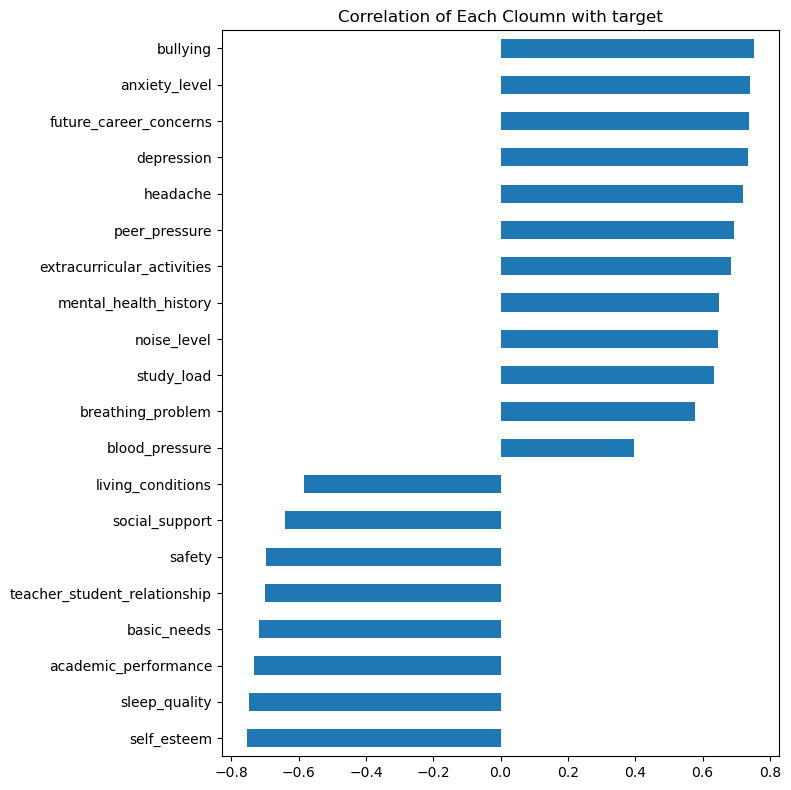

In [23]:
numeric_df = train_df.drop(columns=["target"])
corrs = numeric_df.corrwith(train_df["target"]).sort_values()

plt.figure(figsize=(8,8))
corrs.plot(kind='barh')
plt.title("Correlation of Each Cloumn with target")
plt.tight_layout()
plt.show()

In [24]:
#New Features

#mental_health_score, physical_score, academic_score, social_score

In [25]:
mental_health_cols = ["anxiety_level", "self_esteem", "mental_health_history", "depression"]
physical_cols = ["headache", "blood_pressure", "sleep_quality", "breathing_problem"]
environment_cols = ["noise_level", "living_conditions", "safety", "basic_needs"]
academic_cols = ["academic_performance", "study_load", "teacher_student_relationship", "future_career_concerns"]
social_cols = ["social_support", "peer_pressure", "extracurricular_activities", "bullying"]

for name, cols in [("mental_health_score", mental_health_cols),
                    ("physical_score", physical_cols),
                    ("environment_score", environment_cols),
                    ("academic_score", academic_cols),
                    ("social_score", social_cols)]:
    train_df[name] = train_df[cols].mean(axis=1)
    test_df[name] = test_df[cols].mean(axis=1)

In [26]:
test_df.shape

(220, 26)

In [27]:
train_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,13,25,1,10,2,1,2,2,2,2,...,2,3,3,2,1,12.25,1.75,2.25,2.50,2.50
1,19,11,1,25,4,3,1,5,5,1,...,1,5,5,5,2,14.00,3.25,2.25,2.75,4.00
2,1,25,0,3,1,2,5,1,1,4,...,3,1,2,1,0,7.25,2.25,3.50,2.50,1.75
3,15,10,1,17,4,3,1,5,5,1,...,1,5,4,5,2,10.75,3.25,2.25,2.75,3.75
4,7,27,0,0,1,2,4,2,2,3,...,3,2,1,1,0,8.50,2.25,3.50,2.50,1.75


In [41]:
train_df.shape

(897, 25)

In [28]:
test_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,-0.492268,1.243686,0,-1.500495,-1.064830,-0.225935,1.516182,-0.521307,-1.240155,0.427672,...,1.074062,-0.516479,-0.535859,-1.067918,0,-0.187269,-0.073972,0.408462,0.431044,-0.261548
1,-0.653607,0.795832,0,-1.111445,-1.064830,-0.225935,1.516182,-1.236986,-0.489063,0.427672,...,1.074062,-1.220041,-1.235497,-1.067918,0,-0.242305,-0.252892,0.768175,0.061123,-0.612349
2,0.637107,-0.435767,1,0.833805,1.796392,0.979053,-1.074576,1.625730,0.262029,-0.462047,...,-0.837312,1.594209,1.563055,1.549820,2,0.508786,0.831650,-0.492501,0.583051,0.967443
3,1.443803,-0.323804,1,1.741588,1.081086,0.979053,-1.074576,0.910051,1.013121,-0.462047,...,-0.837312,1.594209,1.563055,0.895385,2,0.965397,0.473904,-0.127178,0.063244,0.803834
4,-0.814946,-0.771658,0,1.482221,1.081086,0.979053,-1.074576,-1.236986,-1.991247,0.427672,...,-0.837312,-0.516479,-1.935135,-1.067918,0,-0.026096,-0.062856,-0.300741,-0.803579,-1.089211


In [29]:
test_df.shape

(220, 26)

In [30]:
train_df.to_csv("../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv", index=False)

In [31]:
test_df.to_csv("../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv", index=False)

In [32]:
scaledStressData = pd.read_csv("../results/outputs/stress_dataset_scaled_full_Stress_Level_dataset.csv")

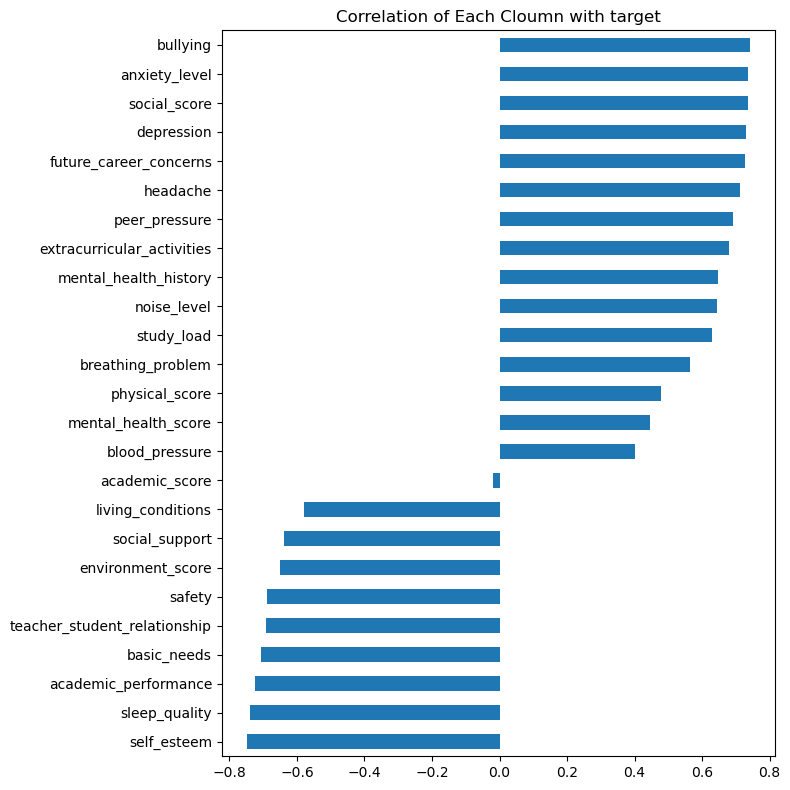

In [33]:
numeric_df = train_df.drop(columns=["target"])
corrs = numeric_df.corrwith(scaledStressData["target"]).sort_values()

plt.figure(figsize=(8,8))
corrs.plot(kind='barh')
plt.title("Correlation of Each Cloumn with target")
plt.tight_layout()
plt.show()

In [34]:
#Accedemic score flagged

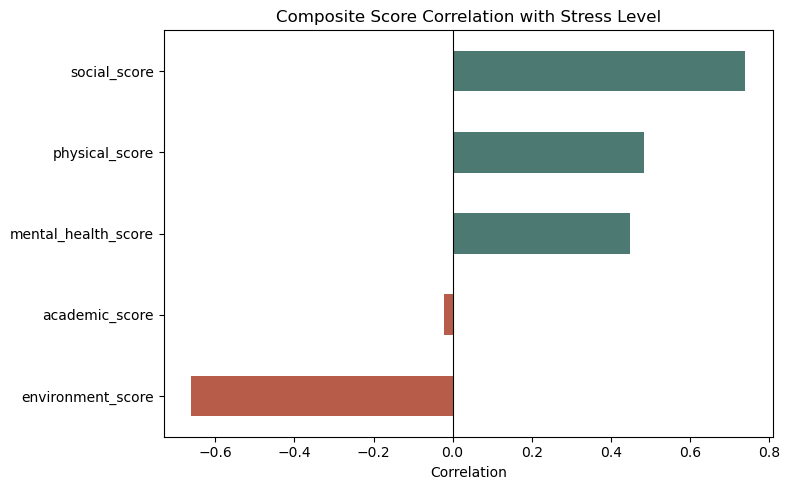

In [35]:
composite_cols = ["mental_health_score", "physical_score", "environment_score", "academic_score", "social_score"]

composite_corr = train_df[composite_cols + ["target"]].corr()["target"].drop("target").sort_values()

plt.figure(figsize=(8, 5))
colors = ['#B85C4A' if v < 0 else '#4C7A73' for v in composite_corr.values]
composite_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Composite Score Correlation with Stress Level")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [36]:
#there for remove academic score

In [37]:
train_df = train_df.drop(columns=["academic_score"])
test_df = test_df.drop(columns=["academic_score"])

print(train_df.columns.tolist()) 

['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'target', 'mental_health_score', 'physical_score', 'environment_score', 'social_score']


In [38]:
test_df.shape

(220, 25)

In [39]:
train_df.to_csv("../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv", index=False)
test_df.to_csv("../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv", index=False)